# Carey (mosquito) and Hallem–Carlson (fly) — what the raw response matrices look like

Two non-binary odorant-receptor datasets, both shipped in the LORAX Zenodo release
(`https://zenodo.org/records/17228740`) and used in the olfactory-foundation-models
benchmark as `CC` and `HC`.

| | CC — Carey et al. | HC — Hallem & Carlson |
|---|---|---|
| species | *Anopheles gambiae* (mosquito) | *Drosophila melanogaster* (fly) |
| matrix | 50 receptors x 110 odorants, **complete** | 24 x 110, **complete** |
| response | continuous, globally z-scored | continuous, globally z-scored |

Unlike M2OR these are dense regression matrices: every pair measured once, no
data-quality tiers, no class imbalance, no missing cells. The point of this notebook
is to look at that structure before deciding how to bring them into the pipeline.

**Ordering, not grouping.** Rows and columns are *seriated* — reordered by
hierarchical clustering so similar receptors and similar odorants sit next to each
other. Nothing is merged or aggregated; every original row and column is still there.

In [1]:
import pathlib, sys
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

_root = pathlib.Path.cwd()
while not (_root / "pyproject.toml").exists():
    _root = _root.parent
RAW = _root / "data" / "external" / "ofm"

# Diverging palette: the response is a z-score, so zero is meaningful -- negative is
# inhibition, positive is activation. Two hues with a NEUTRAL GRAY midpoint (never a
# rainbow, never a hue at the middle), blue for the cool pole and red for the warm.
DIVERGING = LinearSegmentedColormap.from_list(
    "or_response", ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f3a9a8", "#e34948", "#8e1f1e"])
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_MUTED, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "axes.edgecolor": "#d9d8d3", "axes.linewidth": 0.8,
    "xtick.major.size": 0, "ytick.major.size": 0, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

DATASETS = {
    "CC": dict(path=RAW / "CC/raw/CC_reformat_z.csv", receptor="RECEPTOR",
               title="Carey et al. — Anopheles gambiae"),
    "HC": dict(path=RAW / "HC/raw/hc_with_prot_seq_z.csv", receptor="Protein",
               title="Hallem & Carlson — Drosophila melanogaster"),
}
for k, d in DATASETS.items():
    d["df"] = pd.read_csv(d["path"])
    d["mat"] = d["df"].pivot(index=d["receptor"], columns="SMILES", values="output")
    print(f"{k}: {d['df'].shape[0]} rows -> matrix {d['mat'].shape}, "
          f"missing cells {int(d['mat'].isna().sum().sum())}")

CC: 5500 rows -> matrix (50, 110), missing cells 0
HC: 2640 rows -> matrix (24, 110), missing cells 0


## 1. The response is genuinely continuous

The thing that makes these datasets worth having: the label is a graded response, not
a yes/no. Both distributions are sharply peaked just below zero with a long positive
tail — most receptor-odorant pairs do nothing, a few fire hard. Binarising at any
threshold would throw the tail away.

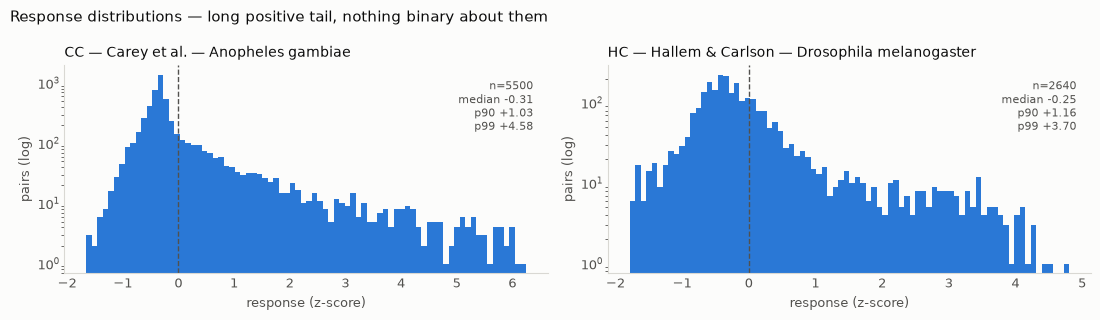

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (k, d) in zip(axes, DATASETS.items()):
    v = d["df"]["output"].to_numpy()
    ax.hist(v, bins=80, color="#2a78d6", edgecolor="none")
    ax.axvline(0, color=INK_MUTED, lw=1, ls="--")
    ax.set_yscale("log")
    ax.set_title(f"{k} — {d['title']}", loc="left", fontsize=10, color=INK)
    ax.set_xlabel("response (z-score)")
    ax.set_ylabel("pairs (log)")
    q = np.percentile(v, [50, 90, 99])
    ax.text(0.97, 0.93, f"n={len(v)}\nmedian {q[0]:+.2f}\np90 {q[1]:+.2f}\np99 {q[2]:+.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK_MUTED)
fig.suptitle("Response distributions — long positive tail, nothing binary about them",
             x=0.005, ha="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## 2. The matrices, seriated

Rows and columns reordered by average-linkage clustering on correlation distance, so
neighbouring receptors have similar tuning and neighbouring odorants elicit similar
patterns. Colour is centred at zero: **blue = below-average response, gray = no signal,
red = activation.** The scale is clipped at the 99th percentile (arrow on the colourbar)
because a handful of very large positive values would otherwise flatten everything else.

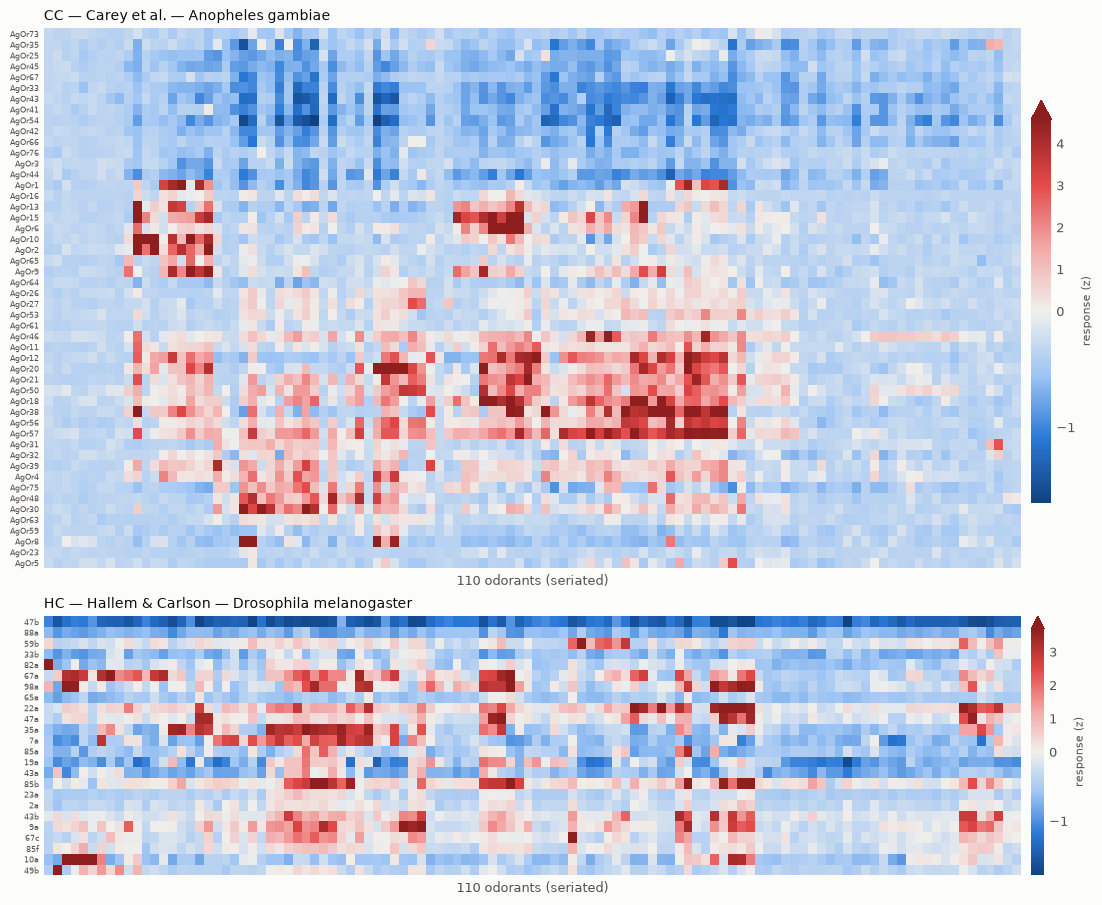

In [3]:
def seriate(mat):
    """Leaf order from average-linkage clustering on correlation distance.
    Falls back to the original order if a row/column is constant (correlation
    distance is undefined there)."""
    def order(x):
        if x.shape[0] < 3:
            return np.arange(x.shape[0])
        d = pdist(x, metric="correlation")
        if not np.isfinite(d).all():
            return np.arange(x.shape[0])
        return leaves_list(linkage(d, method="average"))
    return order(mat.values), order(mat.values.T)


def heatmap(key, ax):
    d = DATASETS[key]
    m = d["mat"]
    r, c = seriate(m)
    m = m.iloc[r, c]
    vmax = np.percentile(m.values, 99)
    norm = TwoSlopeNorm(vmin=float(m.values.min()), vcenter=0.0, vmax=float(vmax))
    im = ax.imshow(m.values, aspect="auto", cmap=DIVERGING, norm=norm, interpolation="nearest")
    ax.set_yticks(range(len(m.index)))
    ax.set_yticklabels(m.index, fontsize=6)
    ax.set_xticks([])
    ax.set_xlabel(f"{m.shape[1]} odorants (seriated)")
    ax.set_title(f"{key} — {d['title']}", loc="left", fontsize=10, color=INK)
    for s in ax.spines.values():
        s.set_visible(False)
    return im


fig, axes = plt.subplots(2, 1, figsize=(13, 11),
                         gridspec_kw={"height_ratios": [50, 24], "hspace": 0.12})
for ax, key in zip(axes, ["CC", "HC"]):
    im = heatmap(key, ax)
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.02, extend="max")
    cb.set_label("response (z)", fontsize=8)
    cb.outline.set_visible(False)
plt.show()

## 3. Tuning breadth

How much of the signal is carried by "this receptor responds to everything" versus
"this odorant activates everything"? Receptors and odorants are sorted independently by
their mean response; the band is the interquartile range across the other axis.

If the receptor curve is much steeper than the odorant curve, then receptor identity
alone explains a lot — the same effect we already know dominates M2OR.

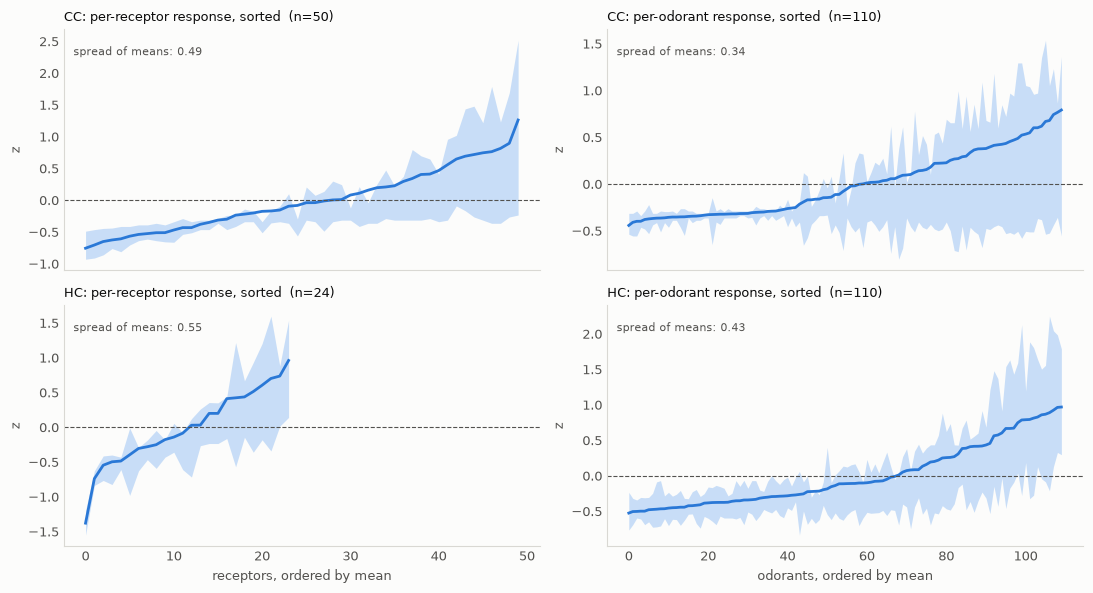

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col")
for row, (k, d) in enumerate(DATASETS.items()):
    m = d["mat"]
    for col, (axis_name, g) in enumerate([("receptor", m), ("odorant", m.T)]):
        ax = axes[row, col]
        stats = pd.DataFrame({"mean": g.mean(axis=1), "q1": g.quantile(.25, axis=1),
                              "q3": g.quantile(.75, axis=1)}).sort_values("mean")
        x = np.arange(len(stats))
        ax.fill_between(x, stats.q1, stats.q3, color="#9ec5f4", alpha=.55, lw=0)
        ax.plot(x, stats["mean"], color="#2a78d6", lw=2)
        ax.axhline(0, color=INK_MUTED, lw=.8, ls="--")
        ax.set_title(f"{k}: per-{axis_name} response, sorted  (n={len(stats)})",
                     loc="left", fontsize=9, color=INK)
        ax.set_ylabel("z")
        if row == 1:
            ax.set_xlabel(f"{axis_name}s, ordered by mean")
        ax.text(.02, .93, f"spread of means: {stats['mean'].std():.2f}",
                transform=ax.transAxes, va="top", fontsize=8, color=INK_MUTED)
fig.tight_layout()
plt.show()

## 4. The two panels overlap — a cross-species handle

Both datasets use 110 odorants, but only part of the panel is shared. Matching on
**SMILES** rather than on the odorant name matters here: many shared structures carry
different names in the two papers.

The shared subset is the natural place to ask whether anything transfers between a
mosquito receptor repertoire and a fly one.

shared SMILES: 50 of 110 each; of those, 21 carry the same name


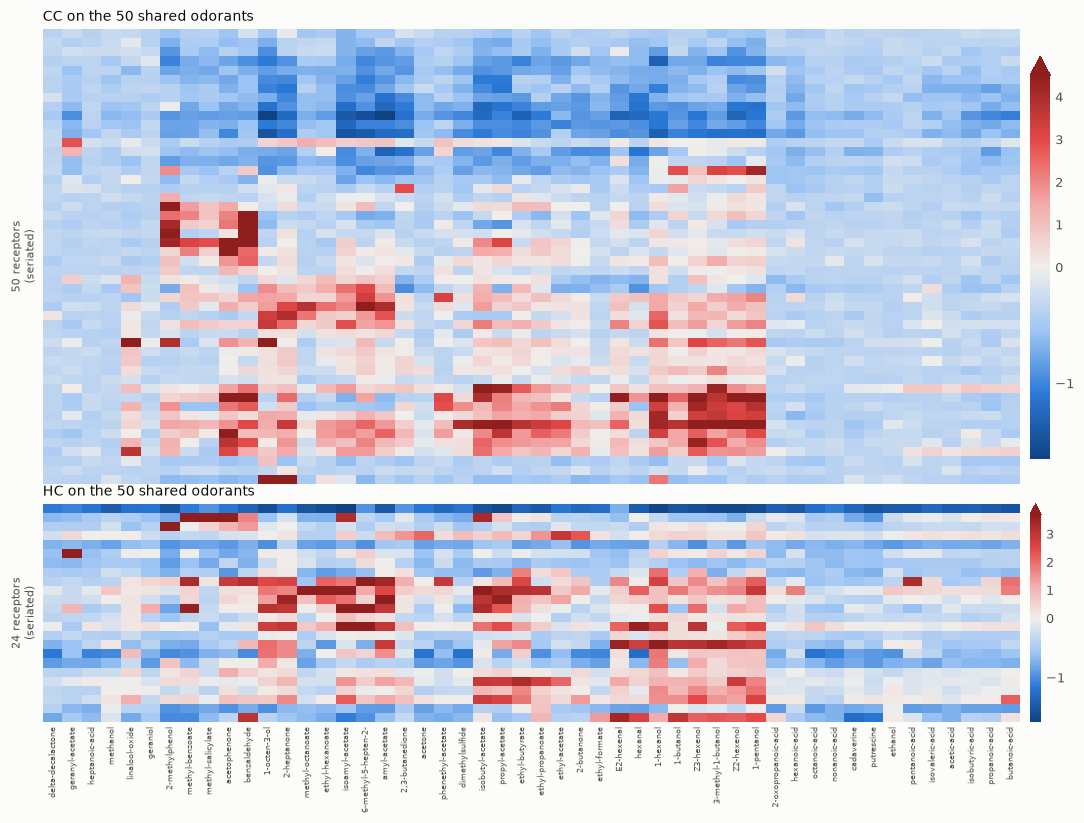

In [5]:
cc, hc = DATASETS["CC"]["mat"], DATASETS["HC"]["mat"]
shared = sorted(set(cc.columns) & set(hc.columns))
names_cc = DATASETS["CC"]["df"].drop_duplicates("SMILES").set_index("SMILES")["odorant"]
names_hc = DATASETS["HC"]["df"].drop_duplicates("SMILES").set_index("SMILES")["odorant"]
same_name = sum(str(names_cc[s]).strip().lower() == str(names_hc[s]).strip().lower() for s in shared)
print(f"shared SMILES: {len(shared)} of 110 each; of those, {same_name} carry the same name")

sub_cc, sub_hc = cc[shared], hc[shared]
# Odorant order is fixed by CC so the two panels are column-comparable; rows are
# seriated per dataset (the two species share no receptor correspondence). Row labels
# are dropped here -- this figure is about the column pattern, and 74 tiny names would
# only collide.
order = leaves_list(linkage(pdist(sub_cc.values.T, metric="correlation"), method="average"))
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={"height_ratios": [50, 24], "hspace": 0.06})
for ax, (k, sub) in zip(axes, [("CC", sub_cc), ("HC", sub_hc)]):
    m = sub.iloc[:, order]
    m = m.iloc[leaves_list(linkage(pdist(m.values, metric="correlation"), method="average"))]
    vmax = np.percentile(m.values, 99)
    im = ax.imshow(m.values, aspect="auto", cmap=DIVERGING,
                   norm=TwoSlopeNorm(vmin=float(m.values.min()), vcenter=0., vmax=float(vmax)),
                   interpolation="nearest")
    ax.set_yticks([])
    ax.set_ylabel(f"{m.shape[0]} receptors\n(seriated)", fontsize=8)
    ax.set_title(f"{k} on the {len(shared)} shared odorants", loc="left", fontsize=10, color=INK)
    if ax is axes[-1]:
        ax.set_xticks(range(len(shared)))
        ax.set_xticklabels([str(names_cc[s])[:20] for s in np.array(shared)[order]],
                           rotation=90, fontsize=6)
    else:
        ax.set_xticks([])
    for s_ in ax.spines.values():
        s_.set_visible(False)
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.02, extend="max")
    cb.outline.set_visible(False)
plt.show()

## Notes for the pipeline

- **Regression, not classification.** Everything downstream of the extractors assumes
  binary labels: `fit_boost` is an `XGBClassifier` with `scale_pos_weight`, the metrics
  are AUROC/AUPRC/MCC/F1, every cls extractor trains on `BCEWithLogitsLoss`, and the
  simplex weighting minimises val log-loss. The upstream benchmark reports **MSE, R² and
  concordance index** on these two.
- **No inchikey column.** Either bridge SMILES to inchikey the way we did for LoRaX, or
  key molecules directly by SMILES — they are canonical and unique here.
- **The Hladiš sample weights do not apply.** One quality tier, no class imbalance,
  complete matrix.
- **CC ships a `cdhit_splits` family** where the test receptors are absent from train —
  a cold-*receptor* regime, which this project has never had a benchmark for. Note
  CD-HIT produced 44 clusters over 50 sequences, so it is closer to a random receptor
  holdout than to the hard "dissimilar family" scenario.